In [2]:
include("RKCQ_weights.jl")

convw_rk (generic function with 1 method)

In [12]:
using BenchmarkTools
RK = 2; α = 0.5 ;  Ks(y) = y^(α); NN = 300; TT = 300; 

W, c = convw_rk(NN,TT,RK, Ks);

  5.458 ns (0 allocations: 0 bytes)


2×2×301 Array{Float64, 3}:
[:, :, 1] =
  1.09868  0.45509
 -0.45509  1.09868

[:, :, 2] =
 -0.160899   -0.843533
 -0.0666464  -0.160899

[:, :, 3] =
 -0.0520062  -0.101991
 -0.0313018  -0.0520062

;;; … 

[:, :, 299] =
 -2.74184e-5  -2.75564e-5
 -2.72815e-5  -2.74184e-5

[:, :, 300] =
 -2.7281e-5   -2.74178e-5
 -2.71452e-5  -2.7281e-5

[:, :, 301] =
 -2.71447e-5  -2.72804e-5
 -2.70101e-5  -2.71447e-5

In [26]:
using NLsolve, SpecialFunctions, Plots, LaTeXStrings, ForwardDiff

nodes = c ;
        
b = [1/12, 5/12, 5/12, 1/12]; 

In [27]:
function LobattoIIIC_4s(q₀ ,  p₀, α ,  N , T)

h = T/N;
    
function Basis(j,t)
        y=1;
         for i in 1:length(nodes)
            if i!=j
             y = y*(t-nodes[i])/(nodes[j]-nodes[i]);    
            end
         end
     return y;
  end 

function dBasis(j,t)
   ForwardDiff.derivative(t->Basis(j,t),t)
end  

lag = map(j-> Basis.(j,c), 1:length(nodes)); lag = stack(lag,dims=1);

dlag = map(j-> dBasis.(j,c), 1:length(nodes)); dlag = stack(dlag,dims=1);

function Q(q,i)
sum(map(k -> q[k] * lag[k,i], 1:length(nodes)))
end

function Qdot(q,i)
sum(map(k -> q[k] * dlag[k,i], 1:length(nodes))) / h; 
end

f(t) = t^3  + 6 * t + (3.2 / gamma(0.5)) * t^2.5; # exact = t^3 for α=0.5    

τ = (0:N)*h;    
    
L(q,v) = (1/2)*(v^2)-(1/2)*(q^2); ∂ᵥL(q,v) = v;  ∂ₓL(t,q,v)  = - q + f(t); 

function  DL(i,q,k)      
  sum(map(a -> b[a] * ∂ᵥL(Q(q,a),Qdot(q,a))  * dlag[i,a] +
            h * b[a] * ∂ₓL(τ[k]+h*c[a],Q(q,a),Qdot(q,a)) * lag[i,a],1:length(c)))
end

function DEL0!(F , x , q₀ , p₀, k)  
    X = vcat(q₀,x[1],x[2],x[3]); 
    F[1] = p₀ + DL(1 , X, k) - b[1] * h^(1-α) * W[1,:,1]' * X ;  
    F[2] = DL(2 , X, k) - b[2] * h^(1-α) * W[2,:,1]' * X ;  
    F[3] = DL(3 , X, k) - b[3] * h^(1-α) * W[3,:,1]' * X ;     
end 

init_gauss = [q₀ + h*p₀/2, q₀ + h*p₀,q₀ + 2*h*p₀]    
    
r = nlsolve((F,x) -> DEL0!(F , x , q₀ , p₀, 1) , init_gauss , autodiff = :forward, ftol=1e-14)

function DEL!(F , x , q , k)  
 X = vcat(q,x[1],x[2],x[3]);  
 qnew =  vcat(q[end],x[1],x[2],x[3]);  
Y = vcat(q[1],q[2],q[3],q);        
F[1] = DL(4,q[end-3:end],k-2) + DL(1,qnew,k-1) - 
     b[1]*h^(1-α) * sum(W[1,:,k-j]'*X[3*j-2:3*j+1] for j in 1:k-1) -
     b[4]*h^(1-α) * sum(W[4,:,k-j]'*Y[3*j-2:3*j+1] for j in 1:k-1) ;  
 
F[2] = DL(2,qnew, k-1) -  b[2]*h^(1-α) * sum(W[2,:,k-j]'*X[3*j-2:3*j+1] for j in 1:k-1); 
F[3] = DL(3,qnew, k-1) -  b[3]*h^(1-α) * sum(W[3,:,k-j]'*X[3*j-2:3*j+1] for j in 1:k-1); 
        
end 

q = [];
append!(q,q₀, r.zero); 

for k in 3:N+1
        
ini_gauss=[q[end-2],q[end-1],q[end]]   
        
r = nlsolve((F,x) -> DEL!(F , x , q, k) , ini_gauss , autodiff = :forward,  ftol=1e-16)
   

append!(q, r.zero)  

        
end 

return q;
    
end



LobattoGalerkin (generic function with 1 method)

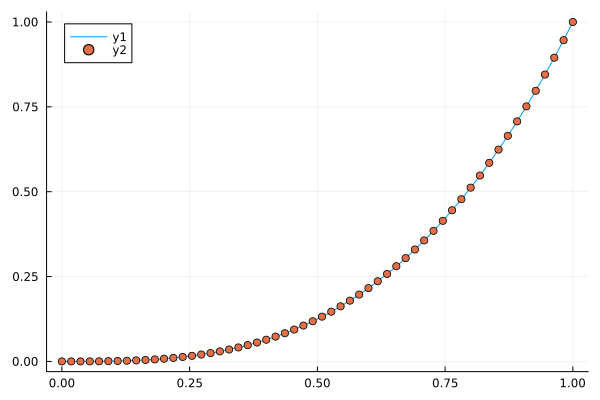

In [28]:
q₀ = 0.0 ;  p₀ = 0.0 ; N = 55 ; T = 1; 

ts = (0:N)*T/N;

exact(t)=t^3;

q = LobattoIIIC_4s(q₀ ,  p₀, α ,  N , T)[1:3:end]

plot(ts,ts .^3)
scatter!(ts,q)

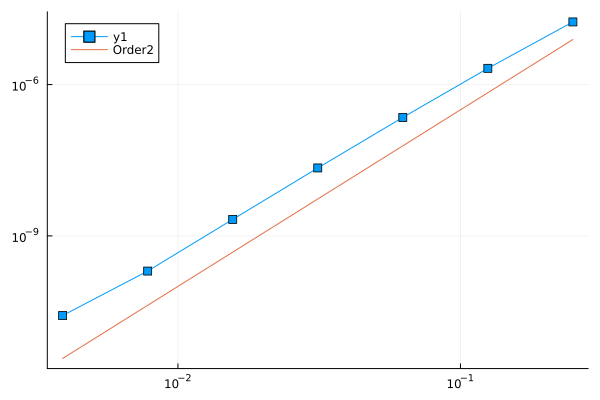

In [34]:
using DelimitedFiles


Ns=2 .^(2:8)

T = 1;

m = length(Ns);

err = zeros(m)

for i in 1:m

N = Ns[i]; ts = (0:N)*T/N;
    
q  = LobattoGalerkin(q₀ ,  p₀, α ,  N , T)[1:3:end]

err[i] = norm(q .- exact.(ts), Inf)
end    

h = T ./Ns;

f(x)=0.001*x^3.5;


plot(h , err , m =:sq)
plot!(h , f.(h) , label="Order2")
plot!(xscale=:log10, yscale=:log10, legend=:topleft)

#savefig("VI_midpointRKCQ")

In [31]:
writedlm("/home/hariz/Desktop/RKCQ_1206/errors/4s_Lob_05.dat", [h err])